In [1]:
import sys
import os
# Get the parent directory of 'clustering folder' (which is 'utils')
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Add 'utils' to Python's module search path
sys.path.append(parent_dir)

#Imports tools
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px
from scipy.stats.mstats import trimmed_var
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from utils import MyTools

In [2]:
df = pd.read_csv("online_retail.csv")
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      525461 non-null  object 
 1   StockCode    525461 non-null  object 
 2   Description  522533 non-null  object 
 3   Quantity     525461 non-null  int64  
 4   InvoiceDate  525461 non-null  object 
 5   Price        525461 non-null  float64
 6   Customer ID  417534 non-null  float64
 7   Country      525461 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.1+ MB


In [4]:
#Convert colume to lower case
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['invoice', 'stockcode', 'description', 'quantity', 'invoicedate',
       'price', 'customer_id', 'country'],
      dtype='object')

In [5]:
mask = (df.price < 0) | (df.price == 0)
df[mask]

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.0,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.0,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.0,NaN,United Kingdom


In [6]:
#Subset the data to price greater than 0
mask = (df.price > 0)
df = df[df.price > 0]
df = df[df.quantity > 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511566 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoice      511566 non-null  object 
 1   stockcode    511566 non-null  object 
 2   description  511566 non-null  object 
 3   quantity     511566 non-null  int64  
 4   invoicedate  511566 non-null  object 
 5   price        511566 non-null  float64
 6   customer_id  407664 non-null  float64
 7   country      511566 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 35.1+ MB


In [7]:
df.dropna(inplace=True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407664 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoice      407664 non-null  object 
 1   stockcode    407664 non-null  object 
 2   description  407664 non-null  object 
 3   quantity     407664 non-null  int64  
 4   invoicedate  407664 non-null  object 
 5   price        407664 non-null  float64
 6   customer_id  407664 non-null  float64
 7   country      407664 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 28.0+ MB


In [9]:
df.isnull().sum()

invoice        0
stockcode      0
description    0
quantity       0
invoicedate    0
price          0
customer_id    0
country        0
dtype: int64

In [10]:
df_uk = df[df["country"] == "United Kingdom"].copy()

In [11]:
df_uk.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [12]:
df_uk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 370929 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoice      370929 non-null  object 
 1   stockcode    370929 non-null  object 
 2   description  370929 non-null  object 
 3   quantity     370929 non-null  int64  
 4   invoicedate  370929 non-null  object 
 5   price        370929 non-null  float64
 6   customer_id  370929 non-null  float64
 7   country      370929 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 25.5+ MB


In [13]:
df_uk.price.describe()

count    370929.000000
mean          3.145406
std          30.552378
min           0.001000
25%           1.250000
50%           1.950000
75%           3.750000
max       10953.500000
Name: price, dtype: float64

In [14]:
#Convert date
df_uk["invoicedate"] = pd.to_datetime(df_uk["invoicedate"])
df_uk["total_amount"] = (df_uk["quantity"] * df_uk["price"])

In [15]:
tools = MyTools(df_uk)

outliers, mask = tools.get_outliers("total_amount")
outliers

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,total_amount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.60
...,...,...,...,...,...,...,...,...,...
525283,538165,22988,SOLDIERS EGG CUP,72,2010-12-09 17:34:00,1.25,14031.0,United Kingdom,90.00
525285,538165,37370,RETRO COFFEE MUGS ASSORTED,72,2010-12-09 17:34:00,1.06,14031.0,United Kingdom,76.32
525303,538167,22086,PAPER CHAIN KIT 50'S CHRISTMAS,40,2010-12-09 18:58:00,2.55,14713.0,United Kingdom,102.00
525356,538168,22086,PAPER CHAIN KIT 50'S CHRISTMAS,13,2010-12-09 19:23:00,2.95,14702.0,United Kingdom,38.35


In [16]:
tools.outlier_pct(len(outliers))

Length of Dataset: 370929
Length of Outlier: 31921
The outlier is 8.61% of the dataset


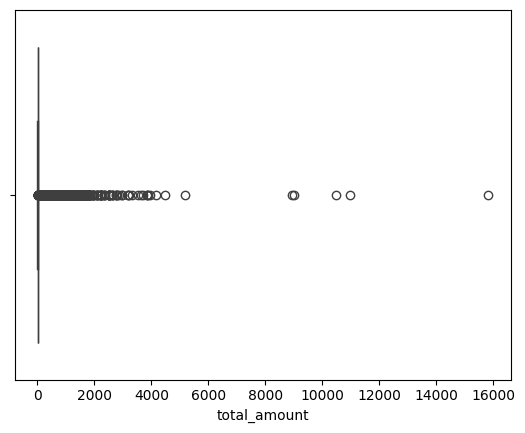

In [17]:
sns.boxplot(df_uk["total_amount"], orient="h", label="Toatal amount");

In [18]:
#Calculate the RMF of for the dataset

# Latest date in the dataset
latest_date = df_uk['invoicedate'].max()
rfm = (
    df_uk
    .groupby("customer_id")
    .aggregate(
        {
            "invoicedate": lambda x:(latest_date - x.max()), # Recency,
            "invoice": "nunique", #Frequency
            "total_amount": "sum" #Monetary
        }
    )
).copy()


In [19]:
rfm.rename(columns={
    'invoicedate': 'recency',
    'invoice': 'frequency',
    'total_amount': 'monetary'
}, inplace=True)


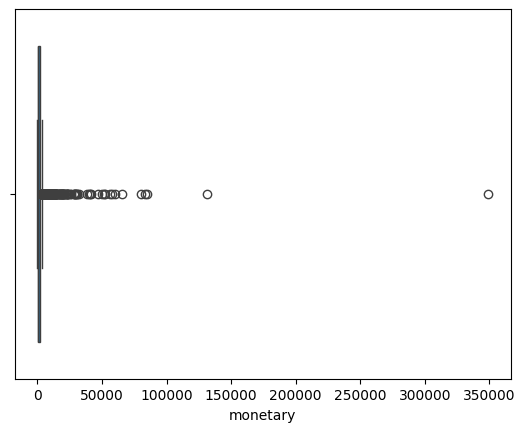

In [20]:
sns.boxplot(rfm["monetary"], orient="h", label="Toatal amount");

In [21]:
rfm_tools = MyTools(rfm)

outliers, mask = rfm_tools.get_outliers("monetary")



In [22]:
rfm_tools.outlier_pct(len(outliers))

Length of Dataset: 3969
Length of Outlier: 387
The outlier is 9.75% of the dataset


In [23]:
outliers.monetary.describe()

count       387.000000
mean      10953.047251
std       21495.762886
min        3686.610000
25%        4423.480000
50%        6001.490000
75%        9691.185000
max      349164.350000
Name: monetary, dtype: float64

In [24]:
rfm = rfm[~mask]
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3582 entries, 12346.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   recency    3582 non-null   timedelta64[ns]
 1   frequency  3582 non-null   int64          
 2   monetary   3582 non-null   float64        
dtypes: float64(1), int64(1), timedelta64[ns](1)
memory usage: 111.9 KB


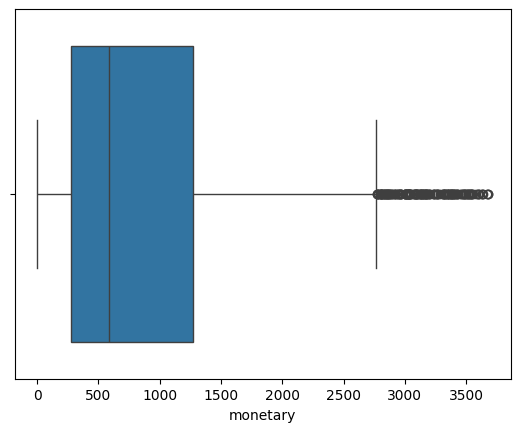

In [25]:
sns.boxplot(rfm["monetary"], orient="h", label="Toatal amount");

In [26]:
rfm.frequency.value_counts()

frequency
1     1300
2      730
3      466
4      341
5      207
6      155
7      131
8       82
9       55
10      44
11      22
12      16
13      10
14       6
18       4
16       4
17       3
20       2
15       2
21       1
62       1
Name: count, dtype: int64

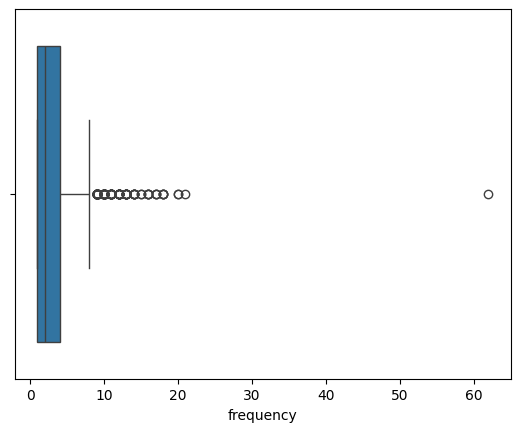

In [27]:
sns.boxplot(rfm["frequency"], orient="h", label="Toatal amount");

In [28]:
rfm["frequency"].describe()

count    3582.000000
mean        3.066164
std         2.797520
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        62.000000
Name: frequency, dtype: float64

In [29]:
rfm_tools = MyTools(rfm)
outliers, mask = rfm_tools.get_outliers("frequency")
rfm_tools.outlier_pct(len(outliers))

Length of Dataset: 3582
Length of Outlier: 170
The outlier is 4.75% of the dataset


In [30]:
rfm = rfm[rfm["frequency"] < 11]
rfm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3511 entries, 12608.0 to 18287.0
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype          
---  ------     --------------  -----          
 0   recency    3511 non-null   timedelta64[ns]
 1   frequency  3511 non-null   int64          
 2   monetary   3511 non-null   float64        
dtypes: float64(1), int64(1), timedelta64[ns](1)
memory usage: 109.7 KB


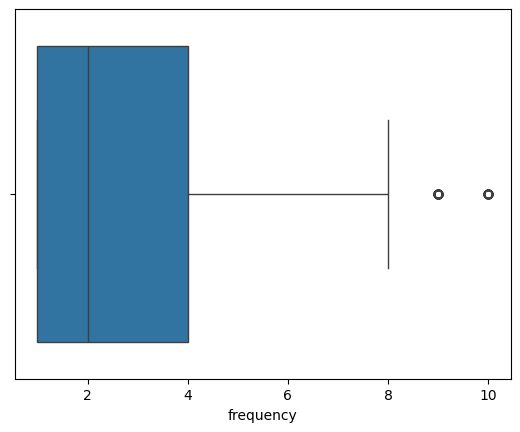

In [31]:
sns.boxplot(rfm["frequency"], orient="h", label="Toatal amount");

In [32]:
rfm.frequency.unique()

array([ 1,  2,  4,  7,  6,  9,  3,  5,  8, 10])

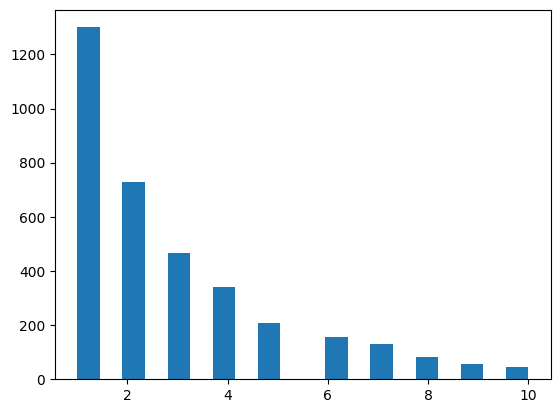

In [37]:
plt.hist(rfm.frequency, bins=20);

In [35]:
#Calculate the RMF score
# Calculate RFM scores
# rfm['r_Score'] = pd.qcut(rfm['recency'], q=5, labels=[5, 4, 3, 2, 1], )  # Lower recency is better
# rfm['f_Score'] = pd.qcut(rfm['frequency'], q=5, labels=[1, 2, 3, 4, 5])  # Higher frequency is better
# rfm['m_Score'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5])  # Higher monetary is better

recency_bins = [
    pd.Timedelta(days=0),    # 0 days
    pd.Timedelta(days=30),   # 30 days
    pd.Timedelta(days=60),   # 60 days
    pd.Timedelta(days=90),   # 90 days
    pd.Timedelta(days=120),  # 120 days
    pd.Timedelta(days=365 * 100)  # A large number to represent infinity
]
frequency_bins = [1, 2, 3, 4, 5, float('inf')]  # Custom bins for Frequency
monetary_bins = [0, 50, 100, 200, 500, float('inf')]  # Custom bins for Monetary

# Assign scores based on custom bins
rfm.loc[:, 'r_Score'] = pd.cut(rfm['recency'], bins=recency_bins, labels=[5, 4, 3, 2, 1])
rfm.loc[:, 'f_Score'] = pd.cut(rfm['frequency'], bins=frequency_bins, labels=[1, 2, 3, 4, 5])
rfm.loc[:, 'm_Score'] = pd.cut(rfm['monetary'], bins=monetary_bins, labels=[1, 2, 3, 4, 5])

#Filll na value
rfm['r_Score'] = rfm['r_Score'].fillna(1).astype(int)
rfm['f_Score'] = rfm['f_Score'].fillna(1).astype(int)
rfm['m_Score'] = rfm['m_Score'].fillna(1).astype(int)

rfm['rfm_Score'] = rfm['r_Score'].astype(int) + rfm['f_Score'].astype(int) + rfm['m_Score'].astype(int)


/var/folders/xk/dqpblzss3wdd3mcn7lz9ldw00000gn/T/ipykernel_2568/1427427861.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['r_Score'] = rfm['r_Score'].fillna(1).astype(int)
/var/folders/xk/dqpblzss3wdd3mcn7lz9ldw00000gn/T/ipykernel_2568/1427427861.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm['f_Score'] = rfm['f_Score'].fillna(1).astype(int)
/var/folders/xk/dqpblzss3wdd3mcn7lz9ldw00000gn/T/ipykernel_2568/1427427861.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

In [ ]:
# n_clusters = ...
# inertia_errors = ...
# silhouette_scores = ...

# # Add `for` loop to train model and calculate inertia, silhouette score.


# print("inertia_errors type:", type(inertia_errors))
# print("inertia_errors len:", len(inertia_errors))
# print("Inertia:", inertia_errors)
# print()
# print("silhouette_scores type:", type(silhouette_scores))
# print("silhouette_scores len:", len(silhouette_scores))
# print("Silhouette Scores:", silhouette_scores)



# # Instantiate transformer
# pca = PCA(n_components=2, random_state=42)

# # Transform `X`
# X_t = pca.fit_transform()

# # Put `X_t` into DataFrame
# X_pca = pd.DataFrame(X_t, columes=["PC1, PC2"])

# print("X_pca type:", type(X_pca))
# print("X_pca shape:", X_pca.shape)
# X_pca.head()

# Create scatter plot of `PC2` vs `PC1`
# fig = px.scattera(
#     data_frame=X_pca,
#     x="PC1",
#     y="PC2",
#     color=labels
# )
# fig.update_layout(xaxis_title="", yaxis_title=")

# fig.show()